## Telco Customer Churn

##### 1. Introduction and Objective

The Telco Customer Churn Database offers a variety of datasets and features that will be utilized in this modeling case study. To gain insights into customer churn retention, I will apply predictive modeling to our pre-processed dataset. My focus will be on three key algorithms: **Logistic Regression (Linear)**, **Random Forest (Bagging)**, and **XGBoost (Boosting)**.

I will enhance model performance through hyperparameter tuning, adjusting parameters such as learning rates and tree depth. The effectiveness of each model will be evaluated using our prepared datasets to ensure reliable insights into customer retention.

#### 2. Data Preparation and Cleaning  

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay


In [97]:
filepath = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\Telco Customer Churn Database\WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco_df = pd.read_csv(filepath)
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [99]:
telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [100]:
telco_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [101]:
# Checking how many missing values are in our dataset
print(telco_df.isna().sum().sort_values())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [102]:
# Handle TotalCharges errors (convert empty strings to 0)
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce').fillna(0)
print(telco_df['TotalCharges'].dtype)

# Drop unique customer identifier and check remaining columns
telco_df = telco_df.drop(columns=['customerID'])
print(telco_df.columns)

float64
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


#### 3. Feature Engineering  

In [103]:
# Convert Binary strings (Yes/No) to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    telco_df[col] = telco_df[col].map({'Yes': 1, 'No': 0})

# Convert Gender to 1/0
telco_df['gender'] = telco_df['gender'].map({'Male': 1, 'Female': 0})

In [104]:
# One-Hot Encoding for all multi-class categorical columns
# This automatically removes the original text columns and prevents the "Dummy Trap"
multi_categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]
telco_dummies = pd.get_dummies(telco_df, columns=multi_categorical_cols, drop_first=True)

#### 4. Exploratory Data Analysis (EDA)

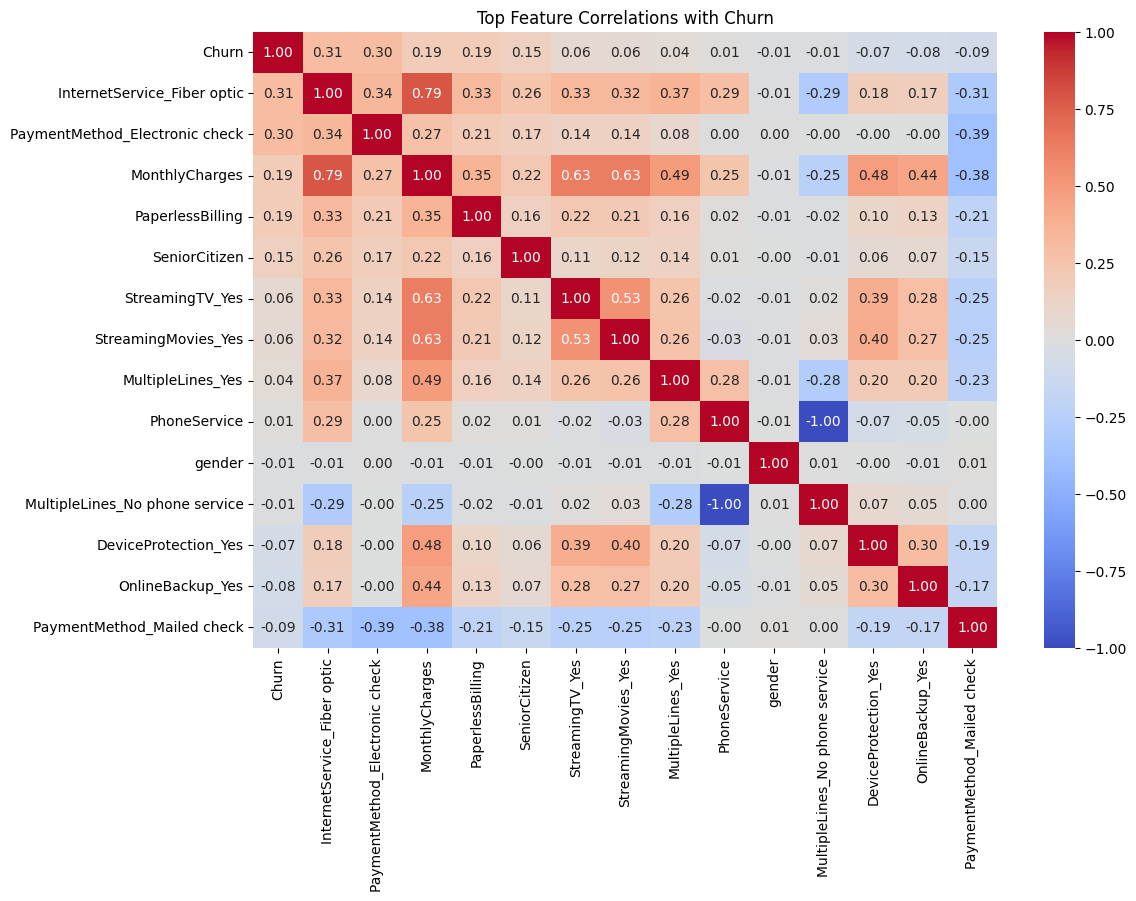

In [105]:
plt.figure(figsize=(12, 8))
# Showing top 15 correlations with Churn
top_corr = telco_dummies.corr()['Churn'].sort_values(ascending=False).head(15)
sns.heatmap(telco_dummies[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Feature Correlations with Churn')
plt.show()

#### 5. Data Splitting and Scaling  

In [106]:
# Prepare data for modeling by separating features and target variable
X = telco_dummies.drop('Churn', axis=1)
y = telco_dummies['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
# Scale numerical features to improve model performance
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#### 6. Model Building

Let’s dive into the modeling steps:

6i. MODEL 1: **Logistic Regression** will serve as our baseline model due to its simplicity and effectiveness for binary classification, allowing us to assess the impact of various features on churn.

In [108]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logreg_model = LogisticRegression(class_weight='balanced', random_state=42)
logreg_model.fit(X_train, y_train)
y_pred_log = logreg_model.predict(X_test)

6ii. MODEL 2: **Random Forest** combines predictions from multiple decision trees, capturing complex interactions and reducing the risk of overfitting.

In [109]:
# Random Forest Model 
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


6iii. Model 3: **Gradient Boosting (XGBoost)** employs boosting techniques to improve accuracy, effectively managing large datasets while providing built-in regularization.

In [110]:
# XGBoost Model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

#### 7. Final Evaluation and Comparison  

In [111]:
print("LOGISTIC REGRESSION REPORT:")
print(classification_report(y_test, y_pred_log))

print("\nRANDOM FOREST REPORT:")
print(classification_report(y_test, y_pred_rf))

print("\nXGBOOST REPORT:")
print(classification_report(y_test, y_pred_xgb))


LOGISTIC REGRESSION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


RANDOM FOREST REPORT:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


XGBOOST REPORT:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weight

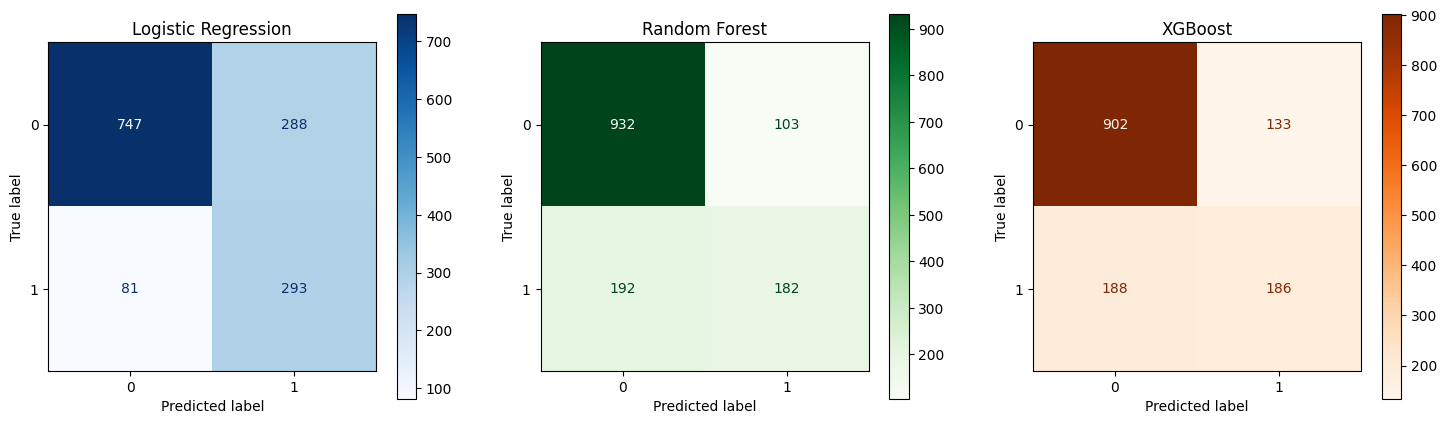

In [112]:
# Visual Comparison of Confusion Matrices
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[2], cmap='Oranges')
axes[2].set_title('XGBoost')
plt.show()

#### 9. Feature Importance (Logistics Regression Coefficients)

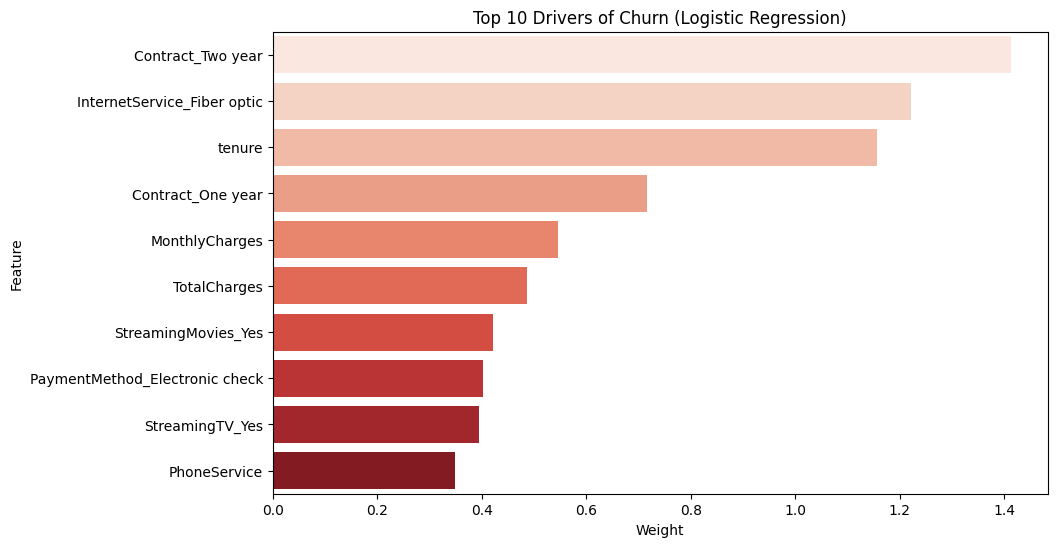

In [113]:
logreg_model_importance = pd.DataFrame({'Feature': X.columns, 'Weight': np.abs(logreg_model.coef_[0])}).sort_values(by='Weight', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=logreg_model_importance.head(10), hue='Feature', palette='Reds', legend=False)
plt.title('Top 10 Drivers of Churn (Logistic Regression)')
plt.show()

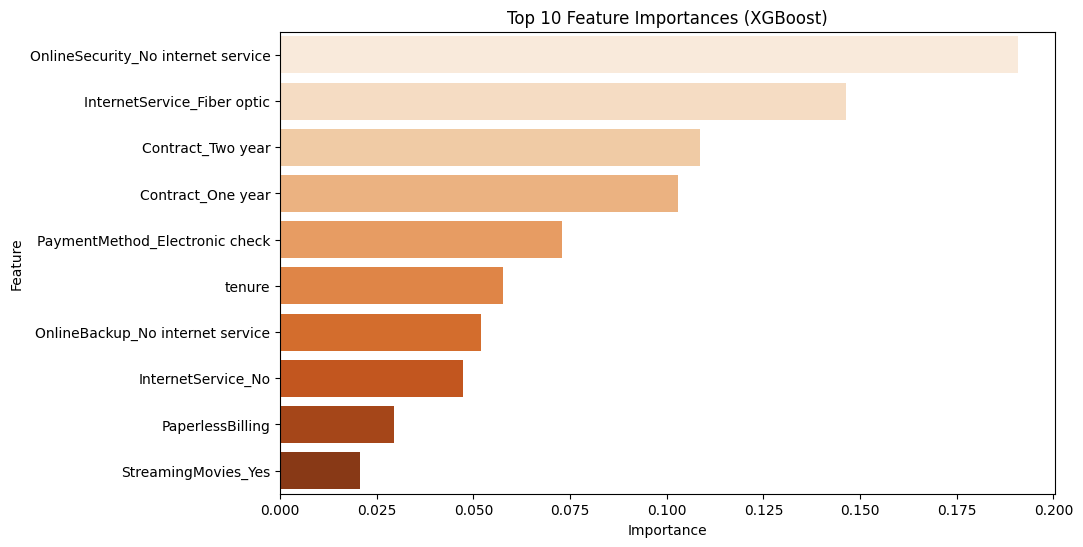

In [114]:
# Extract importance from your tuned XGBoost model
xgb_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': best_model.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(10), hue='Feature', palette='Oranges', legend=False)
plt.title('Top 10 Feature Importances (XGBoost)') # Notice the name change
plt.show()

#### 10. Conclusion

While the Random Forest model boasts the highest overall accuracy at 79%, we strongly recommend using Logistic Regression for business intervention. This model achieved a recall of 78%, successfully identifying 293 actual churners—nearly 60% more than its closest competitors.

The analysis clearly shows that both XGBoost and Logistic Regression identify Contract Type, Internet Service (Fiber Optic), and Tenure as the critical factors influencing customers' decisions to stay or leave.
